In [ ]:
import cobra

# Load SBML model
sbml_file = '/Users/karthik/Desktop/PHCCO IISc Internship/EMT/MODEL1602080000_url.xml'  # Replace with your SBML file path
model = cobra.io.read_sbml_model(sbml_file)

In [12]:
# Extract genes and reactions
genes = model.genes
reactions = model.reactions

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize a directed graph
G = nx.DiGraph()

# Add genes as nodes
for gene in genes:
    G.add_node(gene.id, type='gene')

# Add reactions as nodes and edges
for reaction in reactions:
    G.add_node(reaction.id, type='reaction')
    for gene in reaction.genes:
        # Add edges from genes to reactions
        G.add_edge(gene.id, reaction.id)


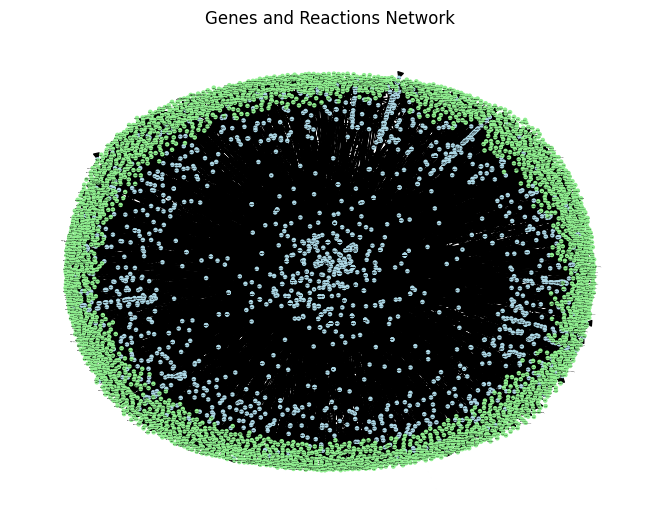

In [14]:
# Draw the graph
pos = nx.spring_layout(G)  # Layout for the nodes
node_colors = {'gene': 'lightblue', 'reaction': 'lightgreen'}
node_types = nx.get_node_attributes(G, 'type')
node_colors = [node_colors[node_types[node]] for node in G.nodes]

nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=5, font_size=1)
plt.title('Genes and Reactions Network')
plt.show()

In [16]:
nx.write_graphml(G, "network.graphml")

In [17]:
# Example: Selecting a subset of nodes based on degree
nodes_of_interest = [n for n, d in G.degree() if d > 5]

# Create a subgraph of G with the selected nodes
G_subset = G.subgraph(nodes_of_interest).copy()


In [23]:
nx.write_graphml(G_subset, 'network_subset.graphml')